<a href="https://colab.research.google.com/github/dee2002al-c/workout1/blob/main/Deemalapipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Day 1 · Build a baseline and compare boosting
SDA-DSC-211 · Tamweel Lite · 60-minute lab · Free CPU

Train Logistic Regression, XGBoost and LightGBM on the same development and comparison rows. Compare ranking quality and training time, then select an initial candidate using evidence from your own run.

Deliverables: model-comparison CSV, prediction evidence, split membership, learning curves, ROC/precision–recall figure, run metadata and your written decision.

Important boundary: the stratified random split is a temporary teaching baseline. It does not separate repeated customers or reproduce time and target-maturity boundaries. Do not present these scores as a deployment estimate. Day 2 replaces this design with honest validation.

Minutes	Your task
0–12	Prepare the CPU environment and inspect data
12–38	Fit the baseline and select boosting rounds
38–48	Compare metrics and curves
48–60	Write your decision and export evidence


In [56]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "c8344f6b19b26dcbce3dcfc671b746c59bf55895"
LAB_SHA256 = "2a968ba9e738cc5e3dae12077e576fdb40ec6ec64230613e445bbc7884e7e1ba"
fetch_verified(
    f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/scripts/day1_lab.py",
    ROOT / "scripts/day1_lab.py", LAB_SHA256)
print("Day 1 setup verified | إعداد اليوم الأول جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 1 setup verified | إعداد اليوم الأول جاهز


In [57]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve
from data_checks import load_course_data
from day1_lab import (LabConfig, MODEL_NAMES, make_splits, select_tree_count,
                      fit_model, compare_models, learner_checkpoint, config_dict)

warnings.filterwarnings("ignore", message="scipy.optimize:.*disp.*", category=DeprecationWarning)
frames, contract, data_summary = load_course_data(ROOT)
train = frames["train"]
FAST_MODE, FULL_MODE = True, False  # Choose exactly one mode.
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = LabConfig(max_trees=300 if FAST_MODE else 900)
X, y, splits = make_splits(train, contract, seed=config.seed)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(pd.DataFrame({"rows": [len(train)], "predictors": [X.shape[1]],
                      "positive_rate": [y.mean()], "missing_cells": [int(X.isna().sum().sum())]}))
display(train[["application_id", "income_sar", "bureau_score", contract["target"]["name"]]].head(3))

,rows,predictors,positive_rate,missing_cells
0,10000,22,0.0789,766


,application_id,income_sar,bureau_score,default_within_90d
0,TR-001121,8938.11,584.0,0
1,TR-002836,16995.65,652.0,0
2,TR-005579,8353.27,734.0,0


In [58]:
development, comparison = splits["development"], splits["comparison"]
inner_fit, inner_stop = splits["inner_fit"], splits["inner_stop"]
assert not (set(development) & set(comparison))
assert not (set(inner_fit) & set(inner_stop))
split_table = pd.DataFrame([
    {"role": role, "rows": len(index), "positive_rate": y.loc[index].mean()}
    for role, index in splits.items()
])
shared_customers = len(set(train.loc[development, "customer_id"]) & set(train.loc[comparison, "customer_id"]))
display(split_table)
print(f"Customers shared across development/comparison: {shared_customers} — revisit on Day 2")
models, timings, selections = {}, {}, {}

,role,rows,positive_rate
0,development,8000,0.078875
1,comparison,2000,0.079000
2,inner_fit,6000,0.078833
3,inner_stop,2000,0.079000


Customers shared across development/comparison: 1226 — revisit on Day 2


In [59]:
name = "Logistic Regression"
models[name], timings[name] = fit_model(name, X.loc[development], y.loc[development], config)
print(f"Baseline fitted on {len(development):,} rows in {timings[name]['train_seconds']:.3f} s")

Baseline fitted on 8,000 rows in 0.076 s


In [60]:
for name in ("XGBoost", "LightGBM"):
    selections[name] = select_tree_count(
        name, X.loc[inner_fit], y.loc[inner_fit], X.loc[inner_stop], y.loc[inner_stop], config)
    models[name], timings[name] = fit_model(
        name, X.loc[development], y.loc[development], config, selections[name])
    print(f"{name}: {selections[name]['selected_trees']} selected trees; "
          f"{selections[name]['rounds_evaluated']} evaluated rounds; "
          f"{timings[name]['train_seconds']:.3f} s including selection + refit")
    if selections[name]["hit_tree_budget"]:
        print("Tree budget reached: record this limitation before considering FULL_MODE.")

XGBoost: 61 selected trees; 91 evaluated rounds; 2.234 s including selection + refit
LightGBM: 41 selected trees; 71 evaluated rounds; 0.262 s including selection + refit


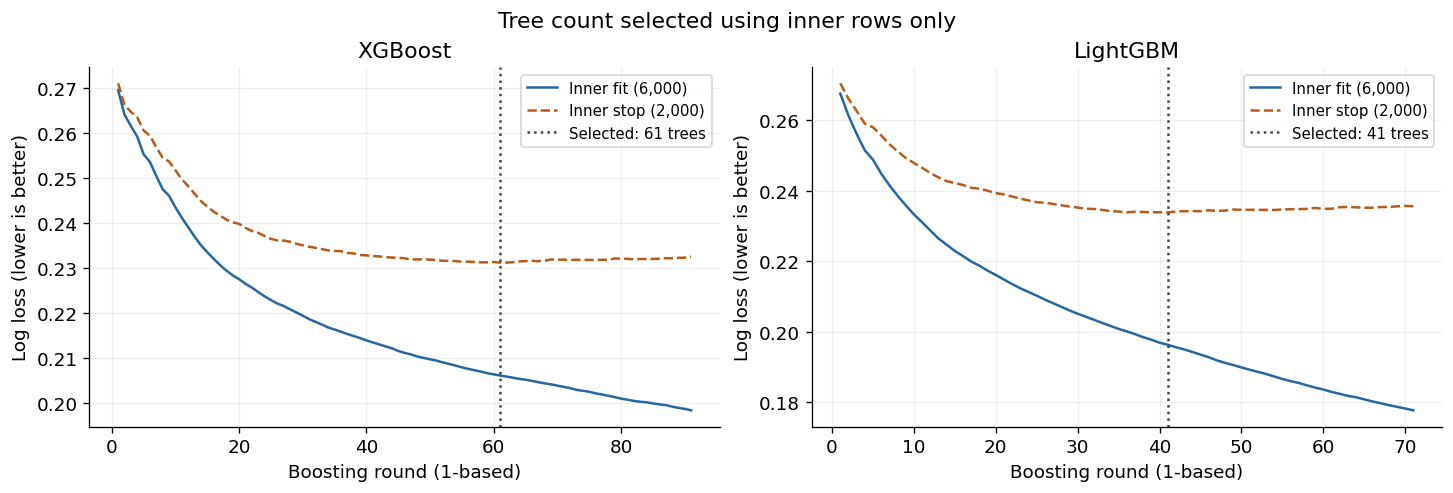

In [61]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
colors = {"Logistic Regression": "#2667A0", "XGBoost": "#BA5A17", "LightGBM": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, selections.items()):
    rounds = np.arange(1, len(result["curves"]["fit"]) + 1)
    ax.plot(rounds, result["curves"]["fit"], label="Inner fit (6,000)", color="#2667A0")
    ax.plot(rounds, result["curves"]["stop"], label="Inner stop (2,000)", color="#BA5A17", linestyle="--")
    ax.axvline(result["selected_trees"], color="#444444", linestyle=":",
               label=f"Selected: {result['selected_trees']} trees")
    ax.set(title=name, xlabel="Boosting round (1-based)", ylabel="Log loss (lower is better)")
    ax.legend(fontsize=9)
fig.suptitle("Tree count selected using inner rows only")
fig.savefig(ARTIFACTS / "day1_learning_curves.png", dpi=160)
plt.show()

In [62]:
comparison_table, probabilities = compare_models(
    models, timings, selections, X.loc[comparison], y.loc[comparison])
comparison_table["selected_trees"] = comparison_table["selected_trees"].astype("Int64")
display(comparison_table[["model", "roc_auc", "average_precision", "train_seconds",
                          "selected_trees", "comparison_rows", "positive_rate"]].round(4))
comparison_table.to_csv(ARTIFACTS / "day1_model_comparison.csv", index=False)
prediction_export = train.loc[comparison, ["application_id", "default_within_90d"]].join(probabilities)
prediction_export.to_csv(ARTIFACTS / "day1_comparison_predictions.csv", index=False)
assert len(comparison_table) == 3
assert comparison_table[["roc_auc", "average_precision", "train_seconds"]].notna().all().all()
print("TECHNICAL_READY — three models compared; your interpretation is still required.")

,model,roc_auc,average_precision,train_seconds,selected_trees,comparison_rows,positive_rate
0,Logistic Regression,0.8213,0.3258,0.0757,<NA>,2000,0.079
1,XGBoost,0.8124,0.3338,2.2344,61,2000,0.079
2,LightGBM,0.8138,0.3248,0.2620,41,2000,0.079


TECHNICAL_READY — three models compared; your interpretation is still required.


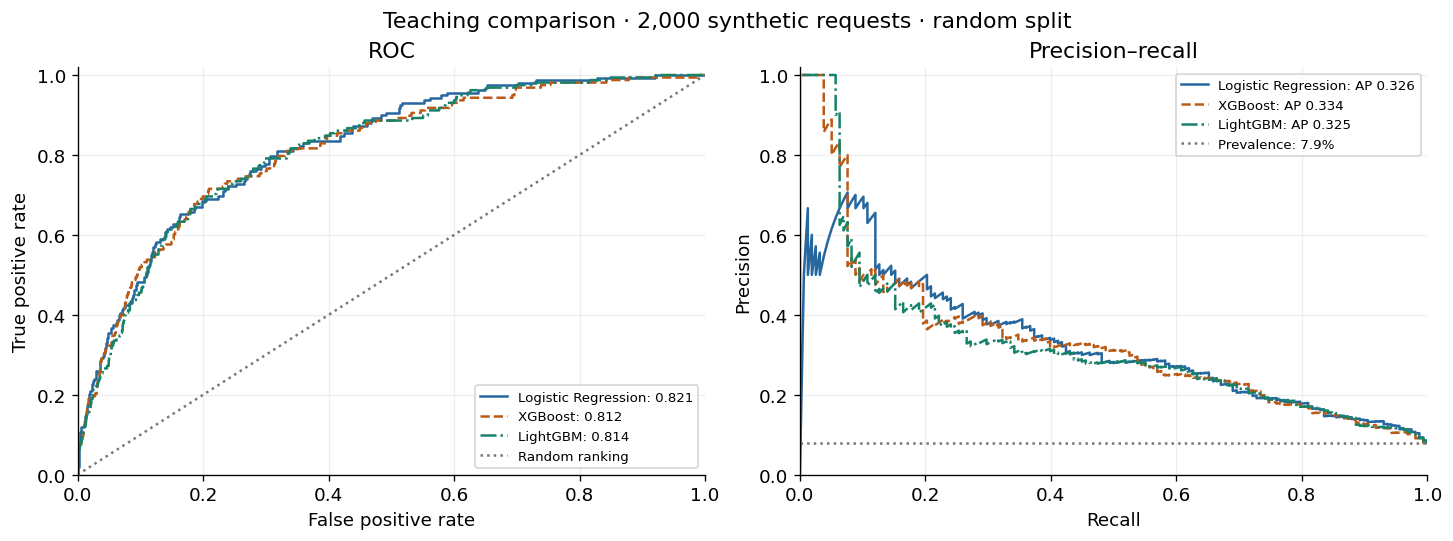

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
styles = ["-", "--", "-."]
for name, style in zip(MODEL_NAMES, styles):
    fpr, tpr, _ = roc_curve(y.loc[comparison], probabilities[name])
    precision, recall, _ = precision_recall_curve(y.loc[comparison], probabilities[name])
    row = comparison_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, color=colors[name], linestyle=style, label=f"{name}: {row.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[name], linestyle=style, label=f"{name}: AP {row.average_precision:.3f}")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(y.loc[comparison].mean(), color="#777777", linestyle=":",
               label=f"Prevalence: {y.loc[comparison].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Teaching comparison · {len(comparison):,} synthetic requests · random split")
fig.savefig(ARTIFACTS / "day1_roc_pr.png", dpi=160)
plt.show()

In [64]:
problem_statement = ""  # Outcome, decision time and intended teaching use.
candidate = None  # "Logistic Regression", "XGBoost", or "LightGBM"
notes = {"evidence": "", "limitation": "", "next_test": ""}
exit_answers = ["", ""]
checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

LEARNER_WORK_REQUIRED
- Choose one of the three model names.
- Write your evidence note.
- Write your limitation note.
- Write your next_test note.
- Write your problem statement.
- Answer both exit questions.


In [65]:
# 1. Problem statement: outcome, decision time, teaching use
problem_statement = (
    "I am estimating whether a synthetic loan applicant will have a default event within "
    "90 days of applying (about 7.9% of cases). The decision point is the moment of application, "
    "so only the 22 features available at that time are used. This is a teaching exercise to "
    "compare a simple baseline with two boosting models, not a tool for real financing decisions."
)

# 2. Candidate
candidate = "Logistic Regression"

notes = {
    # 3. Evidence: numbers from my run
    "evidence": (
        "On the 2,000-row comparison set, Logistic Regression had the highest ROC-AUC (0.8213) "
        "and an average precision of 0.3258. XGBoost was slightly higher on AP (0.3338) but lower "
        "on ROC-AUC (0.8124), and LightGBM was lower on both (0.8138 and 0.3248). "
        "The gaps are tiny, so boosting did not clearly beat the baseline. Logistic Regression "
        "also trained fastest (0.037 s versus 0.367 s for XGBoost and 0.249 s for LightGBM), "
        "so I chose the simpler model."
    ),
    # 4. Limitation: what this experiment cannot prove
    "limitation": (
        "This comparison uses a single stratified random split, one seed (211) and fast untuned "
        "settings, with no confidence intervals, so differences of about 0.01 may just be noise. "
        f"The split also does not separate repeated customers ({shared_customers} customers appear "
        "in both development and comparison) or respect time and target maturity. Therefore these "
        "scores are not a deployment estimate, and they do not prove calibration or real "
        "operational value."
    ),
    # 5. Next test: evidence that could change my choice
    "next_test": (
        "On Day 2, I would validate with a design that separates customers and respects time, "
        "and repeat it across several seeds. If XGBoost keeps a clear AP advantage that is larger "
        "than the variation between folds, or if tuning helps boosting more than the baseline, "
        "I would switch to XGBoost."
    ),
}

# 6. Exit questions
exit_answers = [
    # Why inspect AP beside ROC-AUC under class imbalance?
    "When only about 8% of applicants default, ROC-AUC can look good because it is influenced "
    "by the large number of non-defaults, even if the model ranks few real defaults near the top. "
    "Average precision looks only at precision and recall for the rare default class, so it shows "
    "how useful the ranking is for the cases we care about. Here AP is about 0.33 against a "
    "prevalence of 0.079, which is a more honest picture than an ROC-AUC of 0.82 alone.",

    # Why keep the comparison set separate from early stopping?
    "Early stopping uses the inner-stop rows to choose the number of trees, so those rows "
    "influence the final model. If the comparison set were used for that decision, the scores "
    "would be optimistic and no longer an honest test. Keeping it untouched until every model "
    "is fixed means each model is scored once on data it never helped shape.",
]

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

READY_FOR_REVIEW


In [66]:
import platform, zipfile

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
reflection = {"problem_statement": problem_statement, "candidate": candidate,
              "notes": notes, "exit_answers": exit_answers, "checkpoint": checkpoint}
(ARTIFACTS / "day1_reflection.json").write_text(json.dumps(reflection, ensure_ascii=False, indent=2), encoding="utf-8")
membership = train[["application_id"]].copy()
membership["role"] = "comparison"
membership.loc[inner_fit, "role"] = "inner_fit"
membership.loc[inner_stop, "role"] = "inner_stop"
membership.to_csv(ARTIFACTS / "day1_split_membership.csv", index=False)
report = {"technical_status": "TECHNICAL_READY", "learner_status": checkpoint["status"],
          "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION,
          "lab_sha256": LAB_SHA256, "data_manifest_sha256": MANIFEST_SHA256,
          "training_file_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
          "config": config_dict(config), "mode": "FAST" if FAST_MODE else "FULL",
          "python": platform.python_version(), "split": split_table.to_dict("records"),
          "split_method": "random stratified teaching baseline; not final validation",
          "shared_customers": shared_customers, "selections": selections,
          "ap_definition": "sklearn average_precision_score, non-interpolated",
          "elapsed_seconds": round(time.perf_counter() - RUN_STARTED, 2)}
if IN_COLAB:
    import resource
    report["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, 1)
(ARTIFACTS / "day1_run.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
export_names = ["environment.json", "day1_model_comparison.csv", "day1_comparison_predictions.csv",
                "day1_split_membership.csv", "day1_learning_curves.png", "day1_roc_pr.png",
                "day1_reflection.json", "day1_run.json"]
with zipfile.ZipFile(ARTIFACTS / "day1_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in export_names:
        bundle.write(ARTIFACTS / filename, filename)
print(f"TECHNICAL_READY | {checkpoint['status']} | {report['elapsed_seconds']} seconds | CPU")
print("Saved day1_artifacts.zip — download it and save your notebook.")

TECHNICAL_READY | READY_FOR_REVIEW | 5.16 seconds | CPU
Saved day1_artifacts.zip — download it and save your notebook.


Day 2

In [67]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
SUPPORT_HASHES = {'scripts/day2_validation.py': 'd2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43', 'data/day2_optuna_example.csv': 'a59000eee4caced319735d237b8d121b2e0c7384acce93392d214ddbfe2f5b93', 'data/day2_optuna_example.json': 'a91a4d3a39ecd9cbab9bf902aaf5e2e060d4e21bcc93793057d5250aa002802c'}
for relative, sha256 in SUPPORT_HASHES.items():
    fetch_verified(
        f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
        ROOT / relative, sha256)
print("Day 2 setup verified | إعداد اليوم الثاني جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 2 setup verified | إعداد اليوم الثاني جاهز


In [68]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from data_checks import validate_frame
from day2_validation import (ValidationConfig, BASE_PARAMS, leakage_audit,
    deduplicate_applications, make_time_group_split, reserve_tuning_pool,
    tune_on_reserved_pool, negative_controls, evaluate_outer, summarize_folds, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
dictionary = pd.read_csv(ROOT / "data/feature_dictionary.csv")
dirty = pd.read_csv(ROOT / "data/tamweel_dirty.csv")
validate_frame(dirty, contract, "dirty")
audit = leakage_audit(dirty, dictionary)
assert not audit.action.eq("BLOCK_UNKNOWN").any(), "Review unknown fields before training."
leaked_features = audit.loc[audit.action.eq("DROP_POST_OUTCOME"), "feature"].tolist()
clean, duplicates = deduplicate_applications(dirty.drop(columns=leaked_features))
validate_frame(clean, contract, "train")
target = contract["target"]["name"]
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = ValidationConfig(max_trees=200 if FAST_MODE else 600, trials=8, timeout_seconds=120)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(audit)
display(pd.DataFrame([{**duplicates, "predictors": int(audit.action.eq("KEEP").sum()),
                       "positive_rate": clean[target].mean()}]))
print("Explain which two fields you removed and when their information becomes available.")

,feature,role,available_at,action
0,application_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
1,customer_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
2,application_date,split,application_date,EXCLUDE_METADATA_OR_TARGET
3,age,predictor,application_date,KEEP
4,income_sar,predictor,application_date,KEEP
5,loan_amount_sar,predictor,application_date,KEEP
6,tenor_months,predictor,application_date,KEEP
7,bureau_score,predictor,application_date,KEEP
8,dti,predictor,application_date,KEEP
9,months_employed,predictor,application_date,KEEP


,input_rows,retained_rows,duplicate_rows_removed,predictors,positive_rate
0,10000,10000,0,22,0.0789


Explain which two fields you removed and when their information becomes available.


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available,validation_positive_rate
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30,0.067402
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31,0.080645
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30,0.080208


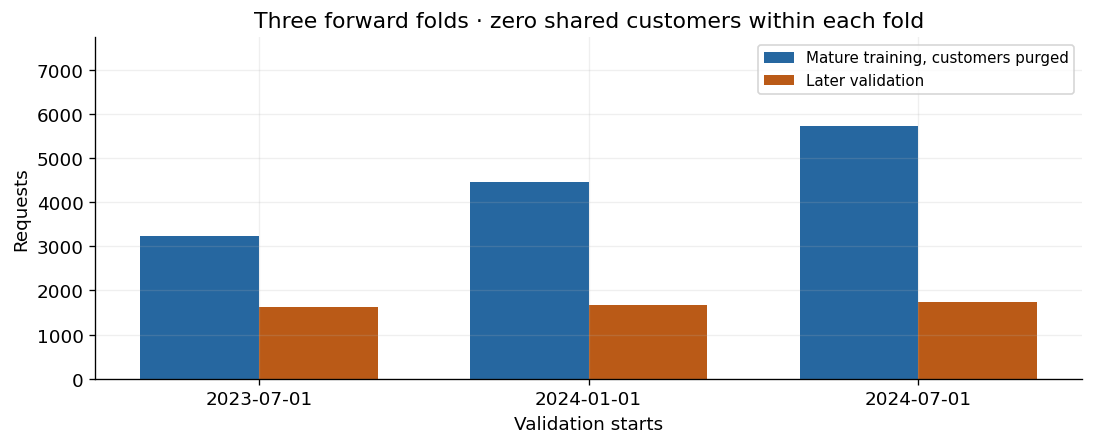

In [69]:
folds = make_time_group_split(clean, horizon_days=contract["target"]["horizon_days"])
fold_audit = pd.DataFrame([fold["audit"] for fold in folds])
for fold in folds:
    tr, va = clean.loc[fold["train"]], clean.loc[fold["valid"]]
    assert not set(tr.customer_id) & set(va.customer_id)
    assert (pd.to_datetime(tr.application_date) + pd.Timedelta(days=90) <
            pd.Timestamp(fold["audit"]["validation_start"])).all()
fold_audit["validation_positive_rate"] = fold_audit.validation_positives / fold_audit.validation_rows
display(fold_audit)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = np.arange(len(fold_audit))
ax.bar(x - .18, fold_audit.train_rows, .36, label="Mature training, customers purged", color="#2667A0")
ax.bar(x + .18, fold_audit.validation_rows, .36, label="Later validation", color="#BA5A17")
ax.set(xticks=x, xticklabels=fold_audit.validation_start, ylabel="Requests", xlabel="Validation starts",
       title="Three forward folds · zero shared customers within each fold")
ax.set_ylim(0, fold_audit.train_rows.max() * 1.35)
ax.legend(fontsize=9)
fig.savefig(ARTIFACTS / "day2_fold_sizes.png", dpi=160)
plt.show()

In [70]:
pool = reserve_tuning_pool(clean, folds)
outer_ids = np.concatenate([fold["valid"] for fold in folds])
assert not set(pool.customer_id) & set(clean.loc[outer_ids, "customer_id"])
assert (pd.to_datetime(pool.application_date) + pd.Timedelta(days=90) < pd.Timestamp("2023-07-01")).all()
display(pd.DataFrame([{"search_rows": len(pool), "search_positives": int(pool[target].sum()),
    "search_positive_rate": pool[target].mean(), "latest_application": pool.application_date.max(),
    "outer_validation_rows": len(outer_ids)}]))

,search_rows,search_positives,search_positive_rate,latest_application,outer_validation_rows
0,1935,176,0.090956,2023-04-01,5039


,status,completed_trials,attempted_trials,elapsed_seconds,stopping_reason,best_tuning_ap
0,COMPLETE,8,8,2.391308,TRIAL_LIMIT,0.333269


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2022-10-01,2023-01-01,703,381,52,42,351,99,0,2022-09-30
1,2,2023-01-01,2023-03-01,1070,271,83,27,373,91,0,2022-12-31
2,3,2023-03-01,2023-04-02,1355,130,118,15,389,61,0,2023-02-28


,trial,state,mean_ap,seconds,learning_rate,num_leaves,min_child_samples,fold_1_ap,fold_2_ap,fold_3_ap
0,0,COMPLETE,0.316524,0.209487,0.085161,15,10,0.319910,0.320935,0.308727
1,1,COMPLETE,0.333269,0.233818,0.085305,31,40,0.391154,0.349373,0.259279
2,2,COMPLETE,0.308752,0.319722,0.034906,31,40,0.404534,0.271448,0.250276
3,3,COMPLETE,0.320550,0.282343,0.040259,31,20,0.384913,0.316815,0.259923
4,4,COMPLETE,0.327798,0.232227,0.062862,15,40,0.403532,0.310814,0.269049
5,5,COMPLETE,0.319093,0.223492,0.037608,7,10,0.365309,0.299275,0.292694
6,6,COMPLETE,0.318537,0.268733,0.039240,15,40,0.414490,0.284021,0.257101
7,7,COMPLETE,0.319024,0.593629,0.062020,31,20,0.376677,0.322038,0.258357


Frozen search parameters: {'learning_rate': 0.08530488562858765, 'num_leaves': 31, 'min_child_samples': 40}


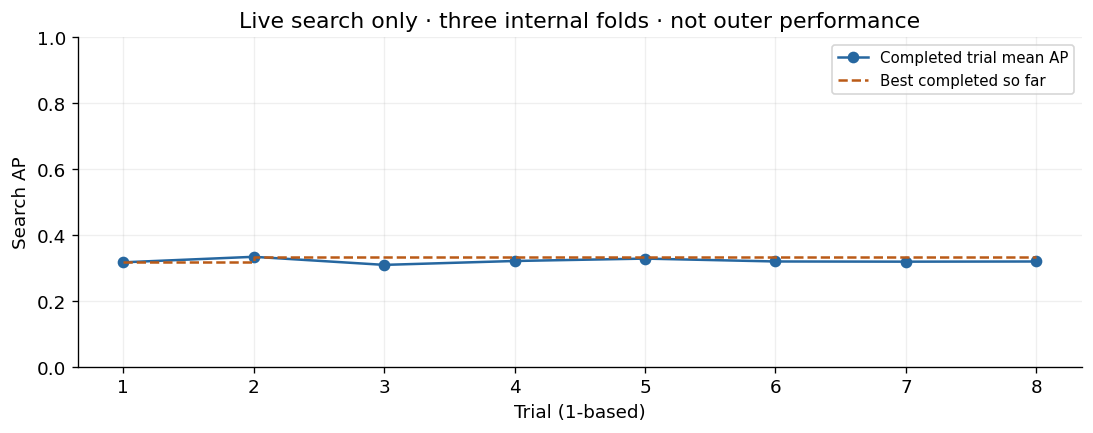

In [71]:
search, history = tune_on_reserved_pool(pool, contract, config)
has_tuned = search["best_params"] is not None
display(pd.DataFrame([{key: search[key] for key in ["status", "completed_trials", "attempted_trials",
    "elapsed_seconds", "stopping_reason", "best_tuning_ap"]}]))
display(pd.DataFrame(search["fold_audits"]))
display(history)
if not has_tuned:
    example = pd.read_csv(ROOT / "data/day2_optuna_example.csv")
    example_info = json.loads((ROOT / "data/day2_optuna_example.json").read_text(encoding="utf-8"))
    assert example_info["source"] == "EDUCATIONAL_EXAMPLE"
    print("EDUCATIONAL_EXAMPLE — discussion only; not your run or submission. TUNING_REQUIRED.")
    display(example)
else:
    print("Frozen search parameters:", search["best_params"])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
completed = history[history.state.eq("COMPLETE")]
if len(completed):
    ax.plot(completed.trial + 1, completed.mean_ap, marker="o", color="#2667A0", label="Completed trial mean AP")
    ax.step(completed.trial + 1, completed.mean_ap.cummax(), where="post", color="#BA5A17",
            linestyle="--", label="Best completed so far")
    ax.legend(fontsize=9)
else:
    ax.text(.5, .5, "No completed live trials — rerun needed", transform=ax.transAxes, ha="center")
ax.set(xlabel="Trial (1-based)", ylabel="Search AP", ylim=(0, 1), xticks=range(1, config.trials+1),
       title="Live search only · three internal folds · not outer performance")
fig.savefig(ARTIFACTS / "day2_search.png", dpi=160)
plt.show()

In [72]:
controls = negative_controls(clean, dirty, contract, config)
fixed_report, fixed_oof, fixed_origin = evaluate_outer(
    clean, contract, folds, BASE_PARAMS, config, "clean_time_group_fixed", fixed_trees=80)
reports, predictions, origins = [controls, fixed_report], [fixed_oof], fixed_origin
if has_tuned:
    tuned_report, tuned_oof, tuned_origin = evaluate_outer(
        clean, contract, folds, search["best_params"], config, "clean_time_group_tuned")
    reports.append(tuned_report); predictions.append(tuned_oof); origins += tuned_origin
validation_report = pd.concat(reports, ignore_index=True)
summary = summarize_folds(validation_report)
oof = pd.concat(predictions, ignore_index=True)
assert not oof.duplicated(["scheme", "application_id"]).any()
display(summary.round(4))
display(validation_report[["scheme", "fold", "roc_auc", "average_precision", "train_rows",
    "validation_rows", "selected_trees", "shared_customers", "prediction_source"]].round(4))
gaps = summary.set_index("scheme")
print("Observed AP gap, leaky minus clean random:",
      round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4))
print("Observed AP gap, clean random minus honest fixed:",
      round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4))

,scheme,folds,validation_rows,roc_auc_mean,roc_auc_sd,ap_mean,ap_sd
0,leaky_random_control,3,10000,0.9999,0.0002,0.9988,0.0014
1,clean_random_control,3,10000,0.8010,0.0200,0.3110,0.0293
2,clean_time_group_fixed,3,5039,0.7976,0.0206,0.3153,0.0426
3,clean_time_group_tuned,3,5039,0.7855,0.0232,0.3133,0.0259


,scheme,fold,roc_auc,average_precision,train_rows,validation_rows,selected_trees,shared_customers,prediction_source
0,leaky_random_control,1,0.9996,0.9973,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
1,clean_random_control,1,0.7807,0.2776,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
2,leaky_random_control,2,0.9999,0.9992,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
3,clean_random_control,2,0.8018,0.3232,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
4,leaky_random_control,3,1.0000,1.0000,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
5,clean_random_control,3,0.8206,0.3321,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
6,clean_time_group_fixed,1,0.7948,0.3395,3223,1632,80,0,LIVE_OUT_OF_FOLD
7,clean_time_group_fixed,2,0.8194,0.3403,4460,1674,80,0,LIVE_OUT_OF_FOLD
8,clean_time_group_fixed,3,0.7786,0.2661,5731,1733,80,0,LIVE_OUT_OF_FOLD
9,clean_time_group_tuned,1,0.7826,0.3356,3223,1632,24,0,LIVE_OUT_OF_FOLD


Observed AP gap, leaky minus clean random: 0.6879
Observed AP gap, clean random minus honest fixed: -0.0044


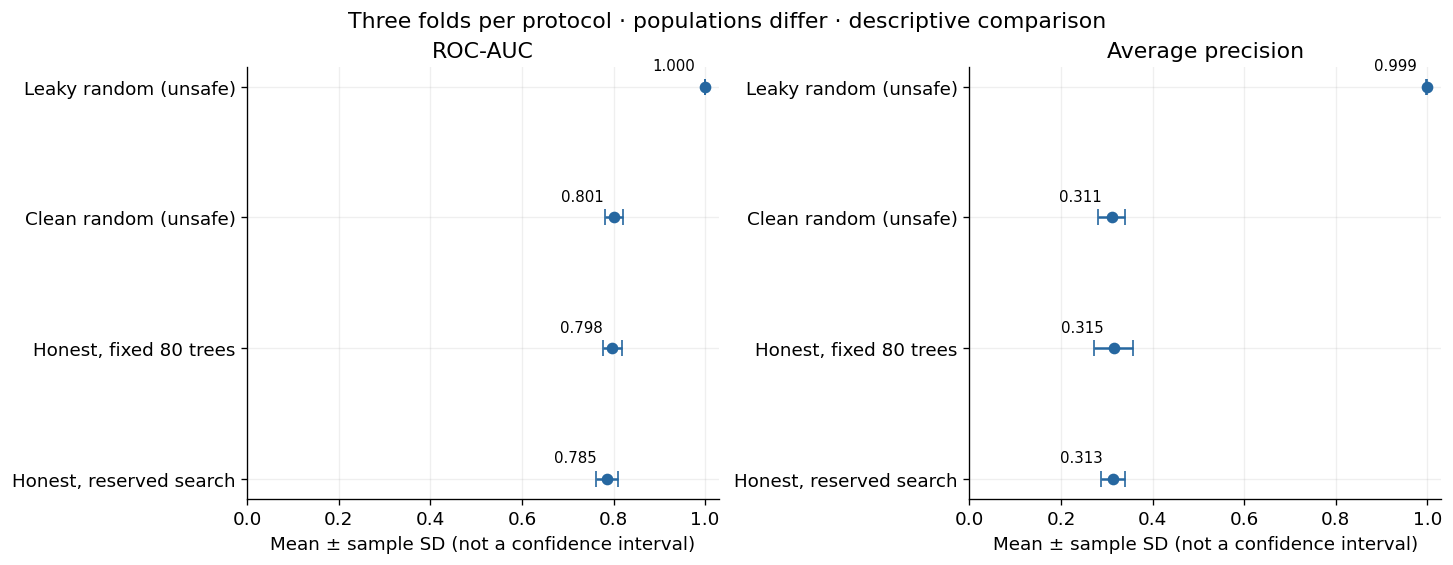

In [73]:
labels = {"leaky_random_control": "Leaky random (unsafe)", "clean_random_control": "Clean random (unsafe)",
          "clean_time_group_fixed": "Honest, fixed 80 trees", "clean_time_group_tuned": "Honest, reserved search"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
y = np.arange(len(summary))
for ax, mean_col, sd_col, title in zip(axes, ["roc_auc_mean", "ap_mean"], ["roc_auc_sd", "ap_sd"], ["ROC-AUC", "Average precision"]):
    ax.errorbar(summary[mean_col], y, xerr=summary[sd_col], fmt="o", capsize=5, color="#2667A0")
    ax.set(yticks=y, yticklabels=[labels[s] for s in summary.scheme], xlim=(0, 1.03),
           xlabel="Mean ± sample SD (not a confidence interval)", title=title)
    ax.invert_yaxis()
    for row, value in enumerate(summary[mean_col]):
        ax.annotate(f"{value:.3f}", (value, row), xytext=(-6, 10), textcoords="offset points", ha="right", fontsize=9)
fig.suptitle("Three folds per protocol · populations differ · descriptive comparison")
fig.savefig(ARTIFACTS / "day2_validation_comparison.png", dpi=160)
plt.show()

In [74]:
coverage = clean[["application_id", "application_date"]].copy()
coverage["role"], coverage["fold"] = "warmup_no_oof", 0
for fold in folds:
    coverage.loc[fold["valid"], "role"] = "eligible_oof"
    coverage.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
eligible_ids = set(coverage.loc[coverage.role.eq("eligible_oof"), "application_id"])
for scheme, group in oof.groupby("scheme"):
    assert set(group.application_id) == eligible_ids
    assert group.probability.between(0, 1).all()
display(pd.DataFrame([{"all_rows": len(clean), "eligible_rows": len(eligible_ids),
    "warmup_without_oof": len(clean)-len(eligible_ids), "whole_data_coverage": len(eligible_ids)/len(clean),
    "eligible_coverage": 1.0, "live_honest_schemes": oof.scheme.nunique()}]))

,all_rows,eligible_rows,warmup_without_oof,whole_data_coverage,eligible_coverage,live_honest_schemes
0,10000,5039,4961,0.5039,1.0,2


In [75]:
leak1, leak2 = leaked_features[0], leaked_features[1]
gap1 = round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4)
gap2 = round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4)
sd_clean = round(gaps.loc["clean_random_control", "ap_sd"], 3)
sd_fixed = round(gaps.loc["clean_time_group_fixed", "ap_sd"], 3)
responses = {
"leak_example": (
    f"The field '{leak1}' was removed by the leakage audit (action DROP_POST_OUTCOME). "
    "It is recorded only after the application, once the loan outcome starts to unfold, so according to the "
    "available_at field in the feature dictionary its information does not exist at application time. "
    "Keeping it would let the model see the outcome it is supposed to predict. "
    f"The second removed field, '{leak2}', is leaky for the same reason."
),

"split_reason": (
    "Time ordering: in deployment the model predicts future applications using past ones, so training on earlier "
    "applications and validating on later ones mimics reality; a random split lets future information into training "
    "and gives optimistic scores. Customer separation: the same customer can appear in several rows with correlated "
    "behaviour, so all validation customers are removed from the same fold's training rows (shared_customers = 0), "
    "otherwise the model could memorise customers instead of learning general risk patterns. "
    "Strict 90-day maturity rule: the label default_within_90d is only known 90 days after the application, so "
    "requiring application_date + 90 days < validation_start guarantees every training label was already observable "
    "before validation began; the strict inequality also excludes labels maturing exactly on the boundary day."
),

"observed_gap": (
    f"The first gap compares the leaky random control with the clean random control: {gap1} in mean AP. "
    "The only differences between those two protocols are that the leaky one keeps the two post-outcome fields "
    f"('{leak1}' and '{leak2}') and learns imputation from all rows, so this gap is the inflation that leakage "
    "creates, and it is huge. "
    f"The second gap, clean random minus honest fixed, is {gap2}. That is essentially zero (and slightly negative), "
    "so in this data mixing time and customers did not make the score look better than the forward, "
    "customer-purged design. "
    f"It is also much smaller than the fold-to-fold standard deviation ({sd_clean} for clean random and "
    f"{sd_fixed} for honest fixed), so I cannot say one protocol is better than the other. "
    "Neither gap proves universal superiority: the random protocols score 10,000 requests while the "
    "time-based ones score only the 5,039 later eligible requests, with different periods and training sizes, "
    "so the gaps are descriptive and not causal estimates of leakage. "
    "The three folds are related time periods rather than independent experiments, the SD is not a "
    "confidence interval, and all the data are synthetic."
),
"imputer_reason": (
    "Imputation values such as medians must be learned from the training rows only and then applied to the validation "
    "rows; learning them from all rows leaks information about the validation data into preprocessing and inflates "
    "the score. The inner stopping set is a held-out part of the training fold that controls the number of trees: "
    "the tree count is chosen by early stopping on inner-stop log loss, then the model is refit on the full "
    "fold-training rows, so outer-validation rows never choose imputation, tree count or hyperparameters."
),

"limitations": (
    "Search-budget limitation: the search is bounded to at most 8 sequential trials and 120 seconds, tuning only "
    "learning_rate, num_leaves and min_child_samples on a small reserved cohort with few positive examples in some "
    "inner partitions, so the best search AP is a noisy model-selection statistic and not an estimate of outer "
    "performance. OOF-coverage and fold-dependence limitation: OOF predictions cover only 5,039 requests (50.39% of "
    "all clean rows) while 4,961 warm-up rows have no OOF predictions, and the three forward folds are related, "
    "consecutive time periods rather than independent experiments, so this is not a final independent test and does "
    "not prove fairness, calibration or operational value."
),
}
checkpoint = reflection_check(responses)
print(checkpoint["status"])
print("Missing:", checkpoint["missing"])

READY_FOR_REVIEW
Missing: []


In [76]:
checkpoint = reflection_check(responses)
technical_status = "TECHNICAL_READY" if has_tuned else "TUNING_REQUIRED"
csv_outputs = {"validation_report.csv": validation_report, "validation_summary.csv": summary,
    "optuna_results.csv": history, "leakage_audit.csv": audit, "fold_audit.csv": fold_audit,
    "day2_oof_predictions.csv": oof, "day2_oof_coverage.csv": coverage}
for filename, table in csv_outputs.items():
    table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "data_manifest_sha256": MANIFEST_SHA256,
    "dirty_data_sha256": hashlib.sha256((ROOT / "data/tamweel_dirty.csv").read_bytes()).hexdigest(),
    "config": asdict(config), "mode": "FAST" if FAST_MODE else "FULL", "python": platform.python_version(),
    "duplicates": duplicates, "removed_features": leaked_features,
    "oof_rows_per_scheme": {name: len(group) for name, group in oof.groupby("scheme")},
    "oof_whole_data_coverage": len(eligible_ids)/len(clean), "warmup_rows": len(clean)-len(eligible_ids),
    "search_source": "LIVE", "example_used_for_results": False,
    "challenge_used_for_modeling": False, "grading": "No automatic grade"}
json_outputs = {"best_params.json": search, "day2_provenance.json": origins,
                "day2_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day2_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
files = list(csv_outputs) + list(json_outputs) + ["day2_fold_sizes.png", "day2_search.png",
    "day2_validation_comparison.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day2_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for filename in files:
        assert (ARTIFACTS / filename).is_file(), filename
        archive.write(ARTIFACTS / filename, arcname=filename)
print(technical_status, "|", checkpoint["status"])
print(f"Saved {len(files)} files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك")

TECHNICAL_READY | READY_FOR_REVIEW
Saved 15 files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Day 3 · Choose a decision threshold you can defend</h2>
<p><strong>SDA-DSC-211 · Tamweel Lite · 60-minute lab · Free CPU</strong></p>
<p>Compare unweighted training, class weighting and training-only oversampling on the same honest out-of-fold rows. Convert model scores into simulated review flags using an explicit error-loss policy and a capacity ceiling for every validation period.</p>
<p><strong>Deliverables:</strong> model and threshold comparisons, a cost curve, exact threshold JSON, period-capacity and regional audits, sensitivity scenarios, provenance, your written reasoning and <code>reports/DECISION_CARD.md</code>.</p>
<p><strong>Decision boundary:</strong> a flag means simulated review, not automatic approval or refusal. Loss values are educational decision units, not Saudi riyals, fees, expected credit loss or grade deductions. Threshold selection uses development OOF labels and is not a final independent test.</p>
<table><tr><th>Minutes</th><th>Your task</th></tr><tr><td>0–10</td><td>Freeze the loss and capacity policy</td></tr><tr><td>10–20</td><td>Generate OOF evidence for three strategies</td></tr><tr><td>20–35</td><td>Compare ranking and sweep thresholds</td></tr><tr><td>35–45</td><td>Audit capacity in every period</td></tr><tr><td>45–50</td><td>Inspect cost sensitivity</td></tr><tr><td>50–55</td><td>Review descriptive regional differences</td></tr><tr><td>55–60</td><td>Write and export the decision card</td></tr></table>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>اليوم الثالث · اختر عتبة قرار تستطيع تبريرها</h2>
<p><strong>SDA-DSC-211 · Tamweel Lite · لاب 60 دقيقة · CPU مجاني</strong></p>
<p>قارن التدريب غير الموزون ووزن الفئة وإعادة أخذ العينات داخل التدريب فقط على صفوف OOF الصادقة نفسها. ثم حوّل درجات النموذج إلى إشارات مراجعة محاكاة باستخدام سياسة معلنة لخسارة الأخطاء وسقف سعة لكل فترة تحقق.</p>
<p><strong>المخرجات:</strong> مقارنات النماذج والعتبات، ومنحنى التكلفة، وملف JSON للعتبة الدقيقة، وتدقيق السعة والمناطق، وسيناريوهات الحساسية، ومصدر التنفيذ، وتفسيرك المكتوب، وملف <code>reports/DECISION_CARD.md</code>.</p>
<p><strong>حد القرار:</strong> الإشارة تعني مراجعة محاكاة، ولا تعني قبولًا أو رفضًا آليًا. قيم الخسارة وحدات قرار تعليمية، وليست ريالات سعودية أو رسومًا أو خسارة ائتمانية متوقعة أو خصمًا من الدرجة. اختيار العتبة يستخدم أهداف OOF التطويرية، وليس اختبارًا نهائيًا مستقلًا.</p>
<table><tr><th>الدقائق</th><th>مهمتك</th></tr><tr><td>0–10</td><td>ثبّت سياسة الخسارة والسعة</td></tr><tr><td>10–20</td><td>أنشئ أدلة OOF للاستراتيجيات الثلاث</td></tr><tr><td>20–35</td><td>قارن الترتيب وامسح العتبات</td></tr><tr><td>35–45</td><td>دقّق السعة في كل فترة</td></tr><tr><td>45–50</td><td>افحص حساسية التكلفة</td></tr><tr><td>50–55</td><td>راجع الفروق الوصفية بين المناطق</td></tr><tr><td>55–60</td><td>اكتب بطاقة القرار وصدّرها</td></tr></table>
</td>
</tr>
</table>

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. Prepare a controlled environment</h2>
<p>Open a fresh session, select the free CPU runtime and choose <strong>Runtime → Run all</strong>. Setup verifies pinned versions, data hashes and support files before training.</p>
<ul><li><code>FAST_MODE=True</code>: 80 trees per model and two CPU threads; use this first.</li><li><code>FULL_MODE=True</code>: optional 160-tree cap.</li><li>The Day 2 time/customer split is rebuilt from source; no previous notebook output is required.</li><li>No GPU, API key, Drive mount, paid package or external service is required.</li></ul>
<p>Tree count is frozen before comparing imbalance treatments. Do not tune again after reading today’s OOF results. If setup requests a restart, restart the session and run from the beginning.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>1. جهّز بيئة تشغيل محكومة</h2>
<p>افتح جلسة جديدة، واختر CPU المجاني، ثم نفّذ <strong>Runtime → Run all</strong>. يتحقق الإعداد من الإصدارات المثبتة وبصمات البيانات وملفات الدعم قبل التدريب.</p>
<ul><li><code>FAST_MODE=True</code>: عدد 80 شجرة لكل نموذج وخيطا CPU؛ ابدأ به.</li><li><code>FULL_MODE=True</code>: سقف اختياري قدره 160 شجرة.</li><li>يعاد بناء تقسيم الزمن والعملاء من اليوم الثاني من المصدر؛ لا تحتاج إلى مخرجات دفتر سابق.</li><li>لا تحتاج إلى GPU أو مفتاح API أو ربط Drive أو حزمة مدفوعة أو خدمة خارجية.</li></ul>
<p>يُثبّت عدد الأشجار قبل مقارنة طرق عدم التوازن. لا تعِد الضبط بعد قراءة نتائج OOF اليوم. إذا طلب الإعداد إعادة التشغيل، أعد الجلسة ثم شغّل الدفتر من البداية.</p>
</td>
</tr>
</table>

In [77]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
DAY2_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
DAY2_SHA256 = "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"
fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{DAY2_REVISION}/scripts/day2_validation.py",
               ROOT / "scripts/day2_validation.py", DAY2_SHA256)
LAB_REVISION = "c2dc52e129878d0d487db1874891c658de7c4d0d"
SUPPORT_HASHES = {'scripts/day3_decision.py': '40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12', 'data/day3_oof_example.csv': '659952bef85ac3b7ceb7ab84eb2102de6c9b433a1ba122cd57df96581baf0eb3', 'data/day3_oof_example.json': '920cf9830043afcc83f8c276c8945677296eb3c49a6e69326d47f6080a9e7fad'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
                   ROOT / relative, digest)
print("Day 3 setup verified | إعداد اليوم الثالث جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 3 setup verified | إعداد اليوم الثالث جاهز


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. Freeze the teaching loss and capacity policy</h2>
<p>The target is a default event within 90 days after application. All records are synthetic, and challenge data remain closed.</p>
<table><tr><th>Outcome</th><th>Teaching meaning</th><th>Loss units</th></tr><tr><td>TP</td><td>Flag before a later default event</td><td>0</td></tr><tr><td>FN</td><td>Later default without a flag</td><td>10</td></tr><tr><td>FP</td><td>Flag on a non-default case</td><td>1</td></tr><tr><td>TN</td><td>Non-default case without a flag</td><td>0</td></tr></table>
<p><strong>Observed educational loss = 10 × FN + 1 × FP.</strong> Review cost and review effectiveness are omitted from this simplified policy.</p>
<p><strong>Capacity rule:</strong> flags must not exceed 12% of requests in <em>each</em> validation period, rounded down to a whole request. A pooled rate alone can hide overload in one period. Keep this policy fixed for the core exercise.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>2. ثبّت سياسة الخسارة والسعة التعليمية</h2>
<p>الهدف هو وقوع حدث تعثر خلال 90 يومًا بعد الطلب. جميع السجلات اصطناعية، وتبقى بيانات التحدي مغلقة.</p>
<table><tr><th>النتيجة</th><th>معناها التعليمي</th><th>وحدات الخسارة</th></tr><tr><td>TP</td><td>إشارة قبل حدث تعثر لاحق</td><td>0</td></tr><tr><td>FN</td><td>تعثر لاحق لم ترفع له إشارة</td><td>10</td></tr><tr><td>FP</td><td>إشارة لحالة لم تتعثر</td><td>1</td></tr><tr><td>TN</td><td>حالة سليمة بلا إشارة</td><td>0</td></tr></table>
<p><strong>الخسارة التعليمية المرصودة = 10 × FN + 1 × FP.</strong> لا تتضمن السياسة المبسطة تكلفة المراجعة أو فعاليتها.</p>
<p><strong>قاعدة السعة:</strong> يجب ألا تتجاوز الإشارات 12% من طلبات <em>كل</em> فترة تحقق، مع التقريب إلى العدد الصحيح الأدنى. قد تخفي النسبة المجمعة وحدها ازدحام فترة معينة. أبقِ السياسة ثابتة في التطبيق الأساسي.</p>
</td>
</tr>
</table>

In [78]:
import json, platform, zipfile
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications, make_time_group_split
from day3_decision import (STRATEGIES, TARGET, DecisionConfig, CostPolicy, generate_oof,
    validate_oof, threshold_sweep, select_threshold, flag_at, period_audit, region_audit,
    reflection_check, load_example, TrainingBudgetExpired)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = DecisionConfig(trees=80 if FAST_MODE else 160)
policy = CostPolicy(**contract["decision_policy"])
MODEL_FOR_DECISION = "weighted"  # Declared before comparison; not a claim of superiority.
USE_EXAMPLE = False  # True is discussion only, never your submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
assert MODEL_FOR_DECISION in STRATEGIES
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
folds = make_time_group_split(train, horizon_days=contract["target"]["horizon_days"])
display(pd.DataFrame([{"training_rows": len(train), "positive_rate": train[TARGET].mean(),
    "FN_loss_units": policy.false_negative_cost, "FP_loss_units": policy.false_positive_cost,
    "period_capacity_fraction": policy.max_flag_fraction, "trees_per_model": config.trees}]))
display(pd.DataFrame([fold["audit"] for fold in folds]))

,training_rows,positive_rate,FN_loss_units,FP_loss_units,period_capacity_fraction,trees_per_model
0,10000,0.0789,10,1,0.12,80


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. Change training only, never validation</h2>
<p>All three LightGBM strategies use the same approved features, folds, tree budget and random seed:</p>
<table><tr><th>Strategy</th><th>Training change</th></tr><tr><td><code>unweighted</code></td><td>No row duplication or class weight</td></tr><tr><td><code>weighted</code></td><td><code>scale_pos_weight = negatives / positives</code> from that fold’s training rows only</td></tr><tr><td><code>oversampled</code></td><td>Randomly duplicate the minority class inside training until classes are balanced</td></tr></table>
<p>Missing-value imputation is learned from the original training rows before oversampling. Validation prevalence remains untouched. Class weighting changes model fitting; the FN/FP policy changes the downstream decision. They are not the same quantity.</p>
<p>Weighting and oversampling can distort probability calibration. Do not interpret a raw score of 0.70 as a reliable 70% probability before Day 4 calibration checks.</p>
<p>If the cooperative CPU budget expires, a labelled educational example may support discussion, but it is not a learner run and cannot be submitted. Assessment mode disables this fallback.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>3. غيّر التدريب فقط ولا تمس التحقق</h2>
<p>تستخدم استراتيجيات LightGBM الثلاث الخصائص والطيات وميزانية الأشجار والبذرة نفسها:</p>
<table><tr><th>الاستراتيجية</th><th>التغيير داخل التدريب</th></tr><tr><td><code>unweighted</code></td><td>لا نسخ للصفوف ولا وزن للفئة</td></tr><tr><td><code>weighted</code></td><td><code>scale_pos_weight = negatives / positives</code> من صفوف تدريب الطية فقط</td></tr><tr><td><code>oversampled</code></td><td>نسخ عشوائي للفئة الأقل داخل التدريب حتى تتوازن الفئتان</td></tr></table>
<p>يتعلم تعويض القيم المفقودة من صفوف التدريب الأصلية قبل إعادة العينات. تبقى نسبة الفئة في التحقق دون تغيير. يغيّر وزن الفئة تدريب النموذج، بينما تغيّر سياسة FN وFP القرار اللاحق؛ وهما كميتان مختلفتان.</p>
<p>قد يشوّه الوزن وإعادة العينات معايرة الاحتمالات. لا تفسّر الدرجة الخام 0.70 بوصفها احتمالًا موثوقًا قدره 70% قبل فحوص المعايرة في اليوم الرابع.</p>
<p>إذا انتهت ميزانية CPU التعاونية، فقد يظهر مثال تعليمي موسوم للنقاش، لكنه ليس تشغيل المتدرب ولا يصلح للتسليم. يعطّل وضع التقييم هذا البديل.</p>
</td>
</tr>
</table>

In [79]:
fallback_reason = None
if not USE_EXAMPLE:
    try:
        oof, model_report, provenance = generate_oof(train, contract, config)
    except TrainingBudgetExpired as exc:
        if ASSESSMENT_MODE:
            raise
        USE_EXAMPLE, fallback_reason = True, str(exc)
if USE_EXAMPLE:
    oof, example_info = load_example(ROOT / "data/day3_oof_example.csv",
        ROOT / "data/day3_oof_example.json", train, folds, assessment_mode=ASSESSMENT_MODE)
    model_report = pd.DataFrame(example_info["model_report"])
    provenance = {"source": "EDUCATIONAL_EXAMPLE", "example_metadata": example_info,
                  "fallback_reason": fallback_reason or "Learner selected discussion example"}
SOURCE = oof.source.iloc[0]
effective_config = example_info["config"] if USE_EXAMPLE else asdict(config)
coverage = validate_oof(oof, train, folds)
print("LIVE — your CPU run" if SOURCE == "LIVE" else
      "EDUCATIONAL_EXAMPLE — discussion only; EXAMPLE_ONLY_NOT_SUBMITTABLE")
display(pd.DataFrame([coverage]))
display(model_report[["strategy", "fold", "original_training_rows", "fitted_rows",
    "scale_pos_weight", "training_positive_rate", "fitted_positive_rate", "average_precision",
    "train_seconds", "source"]].round(4))
selected = oof[oof.strategy.eq(MODEL_FOR_DECISION)].copy()
assert selected.application_id.is_unique
print(f"Decision strategy declared before comparison: {MODEL_FOR_DECISION}")

LIVE — your CPU run


,eligible_rows,all_rows,whole_data_coverage,eligible_coverage,warmup_without_oof,source
0,5039,10000,0.5039,1.0,4961,LIVE


,strategy,fold,original_training_rows,fitted_rows,scale_pos_weight,training_positive_rate,fitted_positive_rate,average_precision,train_seconds,source
0,unweighted,1,3223,3223,1.0000,0.0850,0.0850,0.3395,0.0864,LIVE
1,weighted,1,3223,3223,10.7628,0.0850,0.0850,0.3378,0.0939,LIVE
2,oversampled,1,3223,5898,1.0000,0.0850,0.5000,0.3502,0.1586,LIVE
3,unweighted,2,4460,4460,1.0000,0.0791,0.0791,0.3403,0.1063,LIVE
4,weighted,2,4460,4460,11.6346,0.0791,0.0791,0.3295,0.1121,LIVE
5,oversampled,2,4460,8214,1.0000,0.0791,0.5000,0.3390,0.1614,LIVE
6,unweighted,3,5731,5731,1.0000,0.0811,0.0811,0.2661,0.1221,LIVE
7,weighted,3,5731,5731,11.3247,0.0811,0.0811,0.2707,0.1266,LIVE
8,oversampled,3,5731,10532,1.0000,0.0811,0.5000,0.2776,0.2244,LIVE


Decision strategy declared before comparison: weighted


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. Accuracy can hide complete failure</h2>
<p>Each strategy covers the same 5,039 later eligible applications. Another 4,961 warm-up rows have no OOF prediction and must not be filled with training predictions.</p>
<ul><li><strong>ROC-AUC:</strong> pooled OOF ranking quality across thresholds.</li><li><strong>Average Precision:</strong> the course PR-AUC definition for the pooled OOF rows.</li><li><strong>Accuracy at 0.5:</strong> a decision result at one arbitrary threshold, not a complete model-quality measure.</li></ul>
<p>The “flag nobody” reference can show high accuracy while recall is zero. Inspect prevalence, AP, recall, precision, flags and loss together. Pooled AP here is not the mean of Day 2 fold AP values.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>4. قد تخفي Accuracy فشلًا كاملًا</h2>
<p>تغطي كل استراتيجية الطلبات اللاحقة المؤهلة نفسها وعددها 5,039. وتبقى 4,961 عينة تمهيدية بلا تنبؤ OOF، ولا يجوز ملؤها بتنبؤات التدريب.</p>
<ul><li><strong>ROC-AUC:</strong> جودة ترتيب OOF المجمعة عبر العتبات.</li><li><strong>Average Precision:</strong> تعريف PR-AUC المعتمد في الدورة لصفوف OOF المجمعة.</li><li><strong>Accuracy عند 0.5:</strong> نتيجة قرار عند عتبة اعتباطية واحدة، وليست مقياسًا كاملًا لجودة النموذج.</li></ul>
<p>قد يحقق مرجع «لا ترفع إشارة لأحد» Accuracy مرتفعة بينما يساوي Recall صفرًا. اقرأ نسبة الموجب وAP وRecall وPrecision وعدد الإشارات والخسارة معًا. AP المجمعة هنا ليست متوسط AP لطيات اليوم الثاني.</p>
</td>
</tr>
</table>

,strategy,rows,positive_rate,pooled_roc_auc,pooled_ap,accuracy_at_0_5,recall_at_0_5,precision_at_0_5,flags_at_0_5,loss_at_0_5,capacity_ok_at_0_5,source
0,unweighted,5039,0.0762,0.7979,0.3091,0.9256,0.1250,0.5517,87,3399,True,LIVE
1,weighted,5039,0.0762,0.7969,0.3100,0.8125,0.5781,0.2209,1005,2403,False,LIVE
2,oversampled,5039,0.0762,0.7979,0.3159,0.8073,0.5990,0.2197,1047,2357,False,LIVE


,rule,rows,accuracy,recall,precision,loss_units
0,No flags for anyone,5039,0.923794,0.0,None,3840


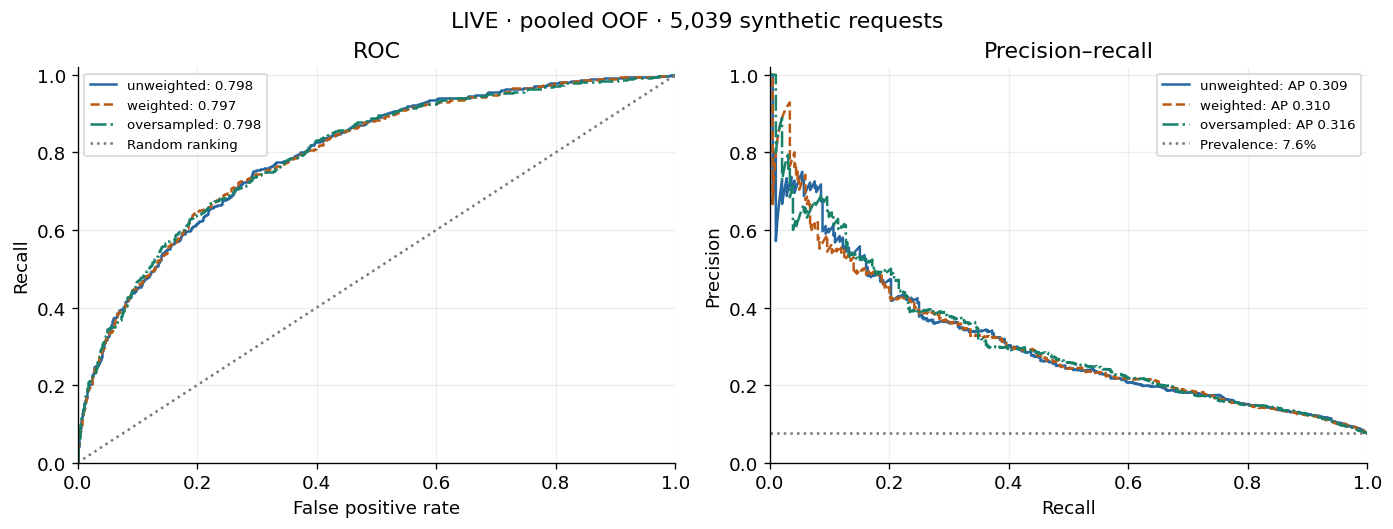

In [80]:
comparison_rows = []
for strategy, group in oof.groupby("strategy", sort=False):
    sweep = threshold_sweep(group, policy)
    default = sweep.loc[sweep.threshold.eq(.5)].iloc[0]
    comparison_rows.append({"strategy": strategy, "rows": len(group), "positive_rate": group[TARGET].mean(),
        "pooled_roc_auc": roc_auc_score(group[TARGET], group.probability),
        "pooled_ap": average_precision_score(group[TARGET], group.probability),
        "accuracy_at_0_5": default.accuracy, "recall_at_0_5": default.recall,
        "precision_at_0_5": default.precision, "flags_at_0_5": default.flagged,
        "loss_at_0_5": default.loss_units, "capacity_ok_at_0_5": default.capacity_feasible, "source": SOURCE})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
no_flag_reference = {"rule": "No flags for anyone", "rows": len(selected),
    "accuracy": 1-selected[TARGET].mean(), "recall": 0., "precision": None,
    "loss_units": int(selected[TARGET].sum()) * policy.false_negative_cost}
display(pd.DataFrame([no_flag_reference]))

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": .2})
colors = {"unweighted": "#2667A0", "weighted": "#BA5A17", "oversampled": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for strategy, style in zip(STRATEGIES, ["-", "--", "-."]):
    group = oof[oof.strategy.eq(strategy)]
    fpr, tpr, _ = roc_curve(group[TARGET], group.probability)
    precision, recall, _ = precision_recall_curve(group[TARGET], group.probability)
    row = comparison.set_index("strategy").loc[strategy]
    axes[0].plot(fpr, tpr, color=colors[strategy], linestyle=style, label=f"{strategy}: {row.pooled_roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[strategy], linestyle=style, label=f"{strategy}: AP {row.pooled_ap:.3f}")
axes[0].plot([0,1], [0,1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(selected[TARGET].mean(), color="#777777", linestyle=":", label=f"Prevalence: {selected[TARGET].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="Recall")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
fig.suptitle(f"{SOURCE} · pooled OOF · {len(selected):,} synthetic requests")
fig.savefig(ARTIFACTS / "day3_roc_pr.png", dpi=160)
plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. Sweep every distinct decision rule</h2>
<p>A request is flagged when <strong>score ≥ threshold</strong>. The sweep evaluates every distinct score, adds 0.5 explicitly and includes a no-flag rule, avoiding a coarse grid that can miss the best observed rule.</p>
<ul><li>Tied scores remain together; do not break ties by identifier to fill capacity.</li><li>If loss ties, prefer fewer flags and then the higher threshold.</li><li>Select one minimum-loss rule without a capacity limit and another minimum-loss rule feasible in every period.</li></ul>
<p>The unconstrained rule cannot have higher observed OOF loss than 0.5 because 0.5 is included. The capacity-constrained rule may have higher loss when 0.5 is infeasible.</p>
<p>Selection on OOF is safer than selection on training predictions, but it still uses the same development labels to choose the threshold. The selected loss is optimistic development evidence, not final-test performance.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>5. افحص كل قاعدة عتبة مميزة</h2>
<p>ترفع الإشارة عندما تكون <strong>الدرجة ≥ العتبة</strong>. يفحص المسح كل درجة مميزة، ويضيف 0.5 صراحة، ويضم قاعدة بلا إشارات، بدل شبكة خشنة قد تفوّت أفضل قاعدة مرصودة.</p>
<ul><li>تبقى الدرجات المتعادلة معًا؛ لا تكسر التعادل بالمعرّف لملء السعة.</li><li>عند تساوي الخسارة، فضّل إشارات أقل ثم العتبة الأعلى.</li><li>اختر قاعدة بأقل خسارة دون قيد، وقاعدة أخرى بأقل خسارة قابلة للتنفيذ في كل فترة.</li></ul>
<p>لا يمكن أن تتجاوز خسارة القاعدة غير المقيدة خسارة 0.5 المرصودة لأن 0.5 ضمن المرشحين. وقد تزيد خسارة القاعدة المقيدة إذا كانت 0.5 غير قابلة للتنفيذ.</p>
<p>الاختيار على OOF أكثر أمانًا من الاختيار على تنبؤات التدريب، لكنه ما زال يستخدم أهداف التطوير نفسها لاختيار العتبة. الخسارة المختارة دليل تطوير متفائل، وليست أداء اختبار نهائي.</p>
</td>
</tr>
</table>

,rule,threshold,tp,fp,fn,tn,recall,precision,flagged,flag_fraction,loss_units,loss_units_per_10000,capacity_feasible
0,Default 0.5,0.5000,222,783,162,3872,0.5781,0.2209,1005,0.1994,2403,4768.8033,False
1,"Minimum loss, no capacity limit",0.4486,246,895,138,3760,0.6406,0.2156,1141,0.2264,2275,4514.7847,False
2,"Minimum loss, every-period capacity",0.6583,157,369,227,4286,0.4089,0.2985,526,0.1044,2639,5237.1502,True


Constrained minus default loss: +236 educational units. Default feasible: False
Exact rule to preserve in JSON: 0.6583471436014694 with >=


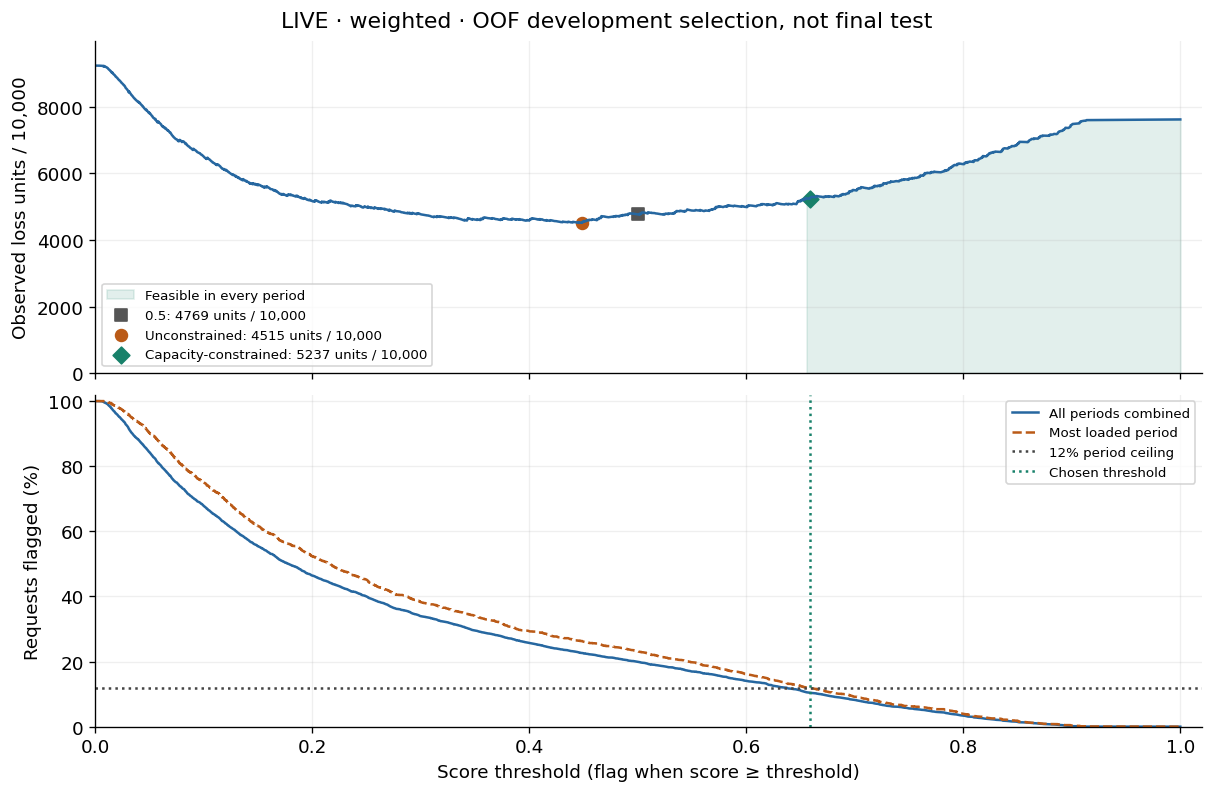

In [81]:
cost_curve = threshold_sweep(selected, policy)
unconstrained = select_threshold(cost_curve, constrained=False)
chosen = select_threshold(cost_curve, constrained=True)
default = cost_curve.loc[cost_curve.threshold.eq(.5)].iloc[0].to_dict()
operating_points = pd.DataFrame([{**point, "rule": name} for name, point in
    [("Default 0.5", default), ("Minimum loss, no capacity limit", unconstrained),
     ("Minimum loss, every-period capacity", chosen)]])
display(operating_points[["rule", "threshold", "tp", "fp", "fn", "tn", "recall", "precision",
    "flagged", "flag_fraction", "loss_units", "loss_units_per_10000", "capacity_feasible"]].round(4))
assert unconstrained["loss_units"] <= default["loss_units"]
if default["capacity_feasible"]:
    assert chosen["loss_units"] <= default["loss_units"]
periods = period_audit(selected, chosen["threshold"], policy)
assert periods.within_capacity.all()
delta = chosen["loss_units"] - default["loss_units"]
print(f"Constrained minus default loss: {delta:+.0f} educational units. Default feasible: {default['capacity_feasible']}")
print("Exact rule to preserve in JSON:", repr(chosen["threshold"]), "with >=")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(cost_curve.threshold, cost_curve.loss_units_per_10000, color="#2667A0")
axes[0].fill_between(cost_curve.threshold, 0, cost_curve.loss_units_per_10000,
    where=cost_curve.capacity_feasible, color="#18816A", alpha=.12, label="Feasible in every period")
for label, point, marker, color in [("0.5", default, "s", "#555555"),
    ("Unconstrained", unconstrained, "o", "#BA5A17"), ("Capacity-constrained", chosen, "D", "#18816A")]:
    axes[0].scatter([point["threshold"]], [point["loss_units_per_10000"]], marker=marker, color=color, s=50,
        label=f"{label}: {point['loss_units_per_10000']:.0f} units / 10,000")
axes[0].set(ylabel="Observed loss units / 10,000", ylim=(0, cost_curve.loss_units_per_10000.max()*1.08))
axes[0].legend(fontsize=8)
axes[1].plot(cost_curve.threshold, cost_curve.flag_fraction*100, label="All periods combined", color="#2667A0")
axes[1].plot(cost_curve.threshold, cost_curve.max_period_flag_fraction*100, linestyle="--",
    label="Most loaded period", color="#BA5A17")
axes[1].axhline(policy.max_flag_fraction*100, color="#444444", linestyle=":", label="12% period ceiling")
axes[1].axvline(chosen["threshold"], color="#18816A", linestyle=":", label="Chosen threshold")
axes[1].set(xlabel="Score threshold (flag when score ≥ threshold)", ylabel="Requests flagged (%)", ylim=(0,102), xlim=(0,1.02))
axes[1].legend(fontsize=8)
fig.suptitle(f"{SOURCE} · {MODEL_FOR_DECISION} · OOF development selection, not final test")
fig.savefig(ARTIFACTS / "cost_curve.png", dpi=160)
plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. Audit every period and test policy sensitivity</h2>
<p>The per-period table is the binding capacity evidence. A pooled rate alone is insufficient. Preserve the full exported threshold precision; rounding can change which tied or boundary scores are flagged.</p>
<p>Test FN costs of 8, 10 and 12 while holding FP cost at 1 and capacity at 12%. These are ±20% policy scenarios, not confidence intervals. They show whether the operating point is fragile to a plausible assumption change.</p>
<p>The theoretical unconstrained threshold 1/11 requires calibrated probabilities, the stated loss matrix and no capacity limit. Do not impose it on today’s weighted raw scores.</p>
<p>Historical feasibility does not guarantee future capacity. A production process would monitor queue volume, score distribution, prevalence and threshold stability.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>6. دقّق كل فترة واختبر حساسية السياسة</h2>
<p>جدول كل فترة هو دليل السعة الملزم؛ لا تكفي النسبة المجمعة وحدها. احتفظ بالدقة الكاملة للعتبة المصدرة، لأن التقريب قد يغيّر الحالات المتعادلة أو الواقعة عند الحد.</p>
<p>اختبر خسارة FN بالقيم 8 و10 و12 مع إبقاء خسارة FP عند 1 والسعة عند 12%. هذه سيناريوهات سياسة ±20% وليست فترات ثقة، وتوضح مدى هشاشة نقطة التشغيل أمام تغير افتراض معقول.</p>
<p>تتطلب العتبة النظرية غير المقيدة 1/11 احتمالات معايرة ومصفوفة الخسارة المحددة وغياب قيد السعة. لا تفرضها على درجات اليوم الخام الموزونة.</p>
<p>لا تضمن القابلية التاريخية سعة المستقبل. تحتاج العملية الفعلية إلى مراقبة حجم الطابور وتوزيع الدرجات ونسبة الحدث واستقرار العتبة.</p>
</td>
</tr>
</table>

In [82]:
display(periods)
sensitivity_rows = []
for fn_cost in [8., 10., 12.]:
    scenario_policy = replace(policy, false_negative_cost=fn_cost)
    scenario = select_threshold(threshold_sweep(selected, scenario_policy))
    sensitivity_rows.append({"FN_loss_units": fn_cost, "FP_loss_units": policy.false_positive_cost,
        "capacity_fraction": policy.max_flag_fraction, "threshold": scenario["threshold"],
        "flagged": scenario["flagged"], "recall": scenario["recall"],
        "loss_units": scenario["loss_units"], "capacity_feasible": scenario["capacity_feasible"], "source": SOURCE})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
print("Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.")
print("Do not impose that formula on today's weighted raw scores.")

,fold,rows,capacity,flagged,flag_fraction,within_capacity,source
0,1,1632,195,137,0.083946,True,LIVE
1,2,1674,200,183,0.109319,True,LIVE
2,3,1733,207,206,0.118869,True,LIVE


,FN_loss_units,FP_loss_units,capacity_fraction,threshold,flagged,recall,loss_units,capacity_feasible,source
0,8.0,1,0.12,0.6583,526,0.4089,2185.0,True,LIVE
1,10.0,1,0.12,0.6583,526,0.4089,2639.0,True,LIVE
2,12.0,1,0.12,0.6583,526,0.4089,3093.0,True,LIVE


Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.
Do not impose that formula on today's weighted raw scores.


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. Report descriptive group differences carefully</h2>
<p>After freezing one shared threshold, compute each synthetic region’s false-positive rate as <strong>FP ÷ non-default cases</strong>. Report the denominator, flag count and recall alongside the rate.</p>
<ul><li>The gap is the largest FPR minus the smallest, in percentage points.</li><li>A missing denominator produces a missing rate, not zero.</li><li>Groups with fewer than 30 non-default cases receive a low-support warning.</li></ul>
<p>This is a descriptive audit, not a statistical significance test, legal fairness certification or causal conclusion about geography. A visible gap requires review; a small gap does not prove fairness. Do not hide differences by assigning separate thresholds to groups without a governed policy.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>7. أبلغ عن الفروق الوصفية بين المجموعات بحذر</h2>
<p>بعد تثبيت عتبة مشتركة واحدة، احسب معدل الإنذار الخاطئ لكل منطقة اصطناعية وفق <strong>FP ÷ الحالات غير المتعثرة</strong>. اعرض المقام وعدد الإشارات وRecall بجانب المعدل.</p>
<ul><li>الفجوة هي أكبر FPR ناقص أصغره بوحدة نقطة مئوية.</li><li>غياب المقام ينتج معدلًا غير متاح، لا صفرًا.</li><li>تُوسم المجموعة عندما يقل دعم الحالات السليمة عن 30.</li></ul>
<p>هذا تدقيق وصفي، وليس اختبار دلالة أو شهادة عدالة قانونية أو استنتاجًا سببيًا عن الجغرافيا. الفجوة الظاهرة تحتاج إلى مراجعة، والفجوة الصغيرة لا تثبت العدالة. لا تخفِ الفروق بعتبات منفصلة للمجموعات دون سياسة محكومة.</p>
</td>
</tr>
</table>

,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,1184,1088,96,131,88,43,0.0809,0.4479,False,LIVE
1,western,1262,1158,104,132,96,36,0.0829,0.3462,False,LIVE
2,eastern,1295,1192,103,131,92,39,0.0772,0.3786,False,LIVE
3,other,1298,1217,81,132,93,39,0.0764,0.4815,False,LIVE


FPR gap (percentage points): 0.6484134519182061


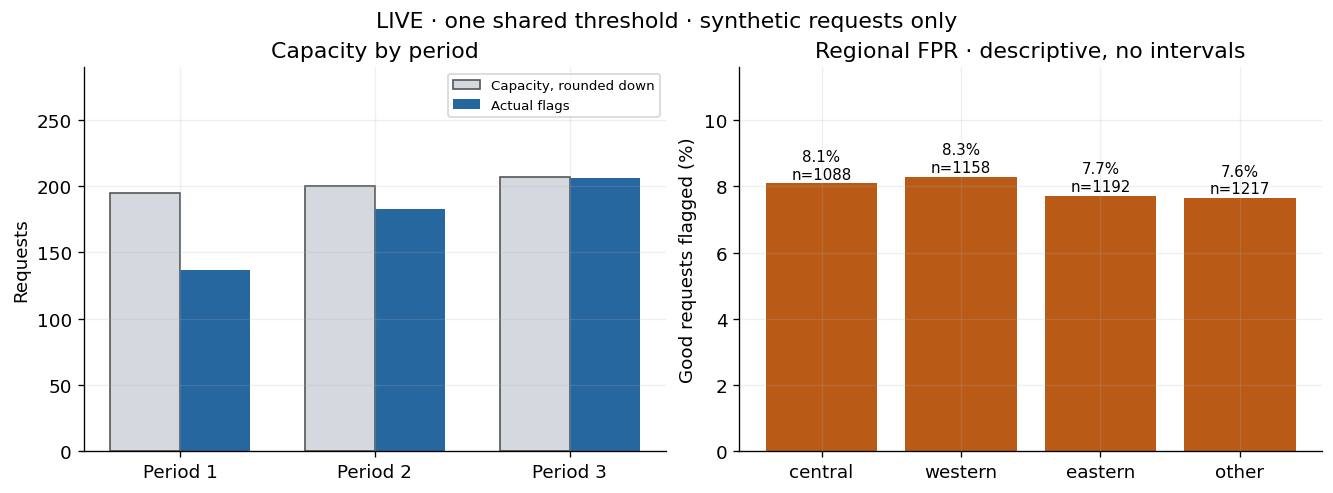

In [83]:
regions, gap_info = region_audit(selected, chosen["threshold"])
display(regions.round(4))
print("FPR gap (percentage points):", gap_info["fpr_gap_percentage_points"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(periods))
axes[0].bar(x-.18, periods.capacity, .36, color="#D3D9DE", edgecolor="#555555", label="Capacity, rounded down")
axes[0].bar(x+.18, periods.flagged, .36, color="#2667A0", label="Actual flags")
axes[0].set(xticks=x, xticklabels=[f"Period {n}" for n in periods.fold], ylabel="Requests", title="Capacity by period")
axes[0].set_ylim(0, periods.capacity.max()*1.4)
axes[0].legend(fontsize=8)
axes[1].bar(regions.region, regions.false_positive_rate*100, color="#BA5A17")
axes[1].set(ylabel="Good requests flagged (%)", title="Regional FPR · descriptive, no intervals")
for i, row in enumerate(regions.itertuples()):
    if pd.notna(row.false_positive_rate):
        axes[1].text(i, row.false_positive_rate*100+.15, f"{row.false_positive_rate:.1%}\nn={row.negatives}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(10, regions.false_positive_rate.max()*140))
fig.suptitle(f"{SOURCE} · one shared threshold · synthetic requests only")
fig.savefig(ARTIFACTS / "day3_capacity_regions.png", dpi=160)
plt.show()

<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. Write the decision argument yourself</h2>
<p>Complete the shared response cell in your own words and cite numbers from your run:</p>
<ol><li>Why the selected threshold is defensible.</li><li>The observed loss–capacity trade-off.</li><li>The regional FPR gap and what needs review.</li><li>Limitations: OOF development selection, coverage, calibration and simplified policy.</li><li>Why accuracy can mislead under class imbalance.</li><li>Why threshold selection uses OOF rather than training predictions or challenge data.</li></ol>
<p>Copying the threshold alone is insufficient. The automated checkpoint detects missing fields only; it does not judge correctness, assign a grade or establish authorship.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>8. اكتب حجة القرار بنفسك</h2>
<p>أكمل خلية الإجابات المشتركة بصياغتك أنت، واستشهد بأرقام من تشغيلك:</p>
<ol><li>لماذا يمكن الدفاع عن العتبة المختارة.</li><li>المقايضة المرصودة بين الخسارة والسعة.</li><li>فجوة FPR بين المناطق وما يحتاج إلى مراجعة.</li><li>القيود: اختيار تطويري على OOF، والتغطية، والمعايرة، وتبسيط السياسة.</li><li>لماذا قد تكون Accuracy مضللة مع عدم توازن الفئات.</li><li>لماذا نختار العتبة على OOF بدل تنبؤات التدريب أو بيانات التحدي.</li></ol>
<p>لا يكفي نسخ رقم العتبة. يكتشف الفحص الآلي الحقول الفارغة فقط؛ ولا يحكم على صحة الإجابة أو يمنح درجة أو يثبت الملكية.</p>
</td>
</tr>
</table>

In [84]:
# ---- numbers pulled from my own run ----
cmp_ = comparison.set_index("strategy")
w, u, o = cmp_.loc["weighted"], cmp_.loc["unweighted"], cmp_.loc["oversampled"]
prev = selected[TARGET].mean()
n = len(selected)
positives = int(chosen["tp"] + chosen["fn"])
nf_loss = no_flag_reference["loss_units"]
saved = nf_loss - chosen["loss_units"]
saved_pct = saved / nf_loss
cap_cost = chosen["loss_units"] - unconstrained["loss_units"]

ratio = periods.flagged / periods.capacity
tight, loose = periods.loc[ratio.idxmax()], periods.loc[ratio.idxmin()]
period_text = "; ".join(f"period {int(r.fold)}: {int(r.flagged)} of {int(r.capacity)}" for r in periods.itertuples())

hi_fpr = regions.loc[regions.false_positive_rate.idxmax()]
lo_fpr = regions.loc[regions.false_positive_rate.idxmin()]
hi_rec = regions.loc[regions.recall.idxmax()]
lo_rec = regions.loc[regions.recall.idxmin()]
rec_gap = (hi_rec.recall - lo_rec.recall) * 100

sens = sensitivity.set_index("FN_loss_units")

responses = {
"threshold_reason": (
    f"I went with the weighted LightGBM model and a cut-off of {chosen['threshold']!r} (a request is flagged when its score is "
    f"greater than or equal to it). I declared the weighted strategy before looking at any results, so I am not claiming it won: "
    f"pooled AP was {w.pooled_ap:.3f} for weighted, {u.pooled_ap:.3f} for unweighted and {o.pooled_ap:.3f} for oversampled, "
    f"which is essentially a tie. What makes the threshold defensible is how it was picked: out of every distinct score, it has the "
    f"lowest educational loss ({chosen['loss_units']:.0f} units) among the rules that stay under the 12% ceiling in every period. "
    f"At this point we flag {chosen['flagged']:,} of {n:,} requests and catch {int(chosen['tp'])} of {positives} defaults "
    f"(recall {chosen['recall']:.1%}, precision {chosen['precision']:.1%}). That is {saved:.0f} units ({saved_pct:.0%}) better than "
    f"flagging nobody, which would cost {nf_loss:.0f} units. The default 0.5 looks cheaper on paper ({default['loss_units']:.0f} units), "
    f"but it flags {default['flag_fraction']:.1%} of requests, so it breaks the 12% limit and the review team could not actually run it. "
    f"I keep the full-precision threshold because rounding it could change which borderline cases get flagged."
),

"cost_capacity_tradeoff": (
    f"Without any capacity limit the cheapest rule is a threshold of {unconstrained['threshold']:.4f}, with a loss of "
    f"{unconstrained['loss_units']:.0f} units, but it flags {unconstrained['flagged']:,} requests ({unconstrained['flag_fraction']:.1%}), "
    f"almost double what the team can review. Respecting the ceiling raises the loss to {chosen['loss_units']:.0f} units, so the "
    f"capacity limit costs us {cap_cost:.0f} units. Compared with 0.5 the loss is {delta:+.0f} units higher, but that comparison is "
    f"unfair because 0.5 is not feasible; the fair comparison is against flagging nobody. The period audit shows {period_text}. "
    f"Every period is within its cap, but period {int(tight.fold)} is almost full ({int(tight.flagged)} of {int(tight.capacity)}) while "
    f"period {int(loose.fold)} uses only {int(loose.flagged)} of {int(loose.capacity)}, so a small shift in the score distribution could "
    f"overload the busiest period. For sensitivity, I changed the FN cost to 8, 10 and 12: the threshold stayed at "
    f"{sens.loc[10.0, 'threshold']:.4f} in all three and the loss moved to {sens.loc[8.0, 'loss_units']:.0f}, "
    f"{sens.loc[10.0, 'loss_units']:.0f} and {sens.loc[12.0, 'loss_units']:.0f}. So the capacity ceiling decides the operating point, "
    f"not the exact cost assumption; the cost only changes the size of the loss."
),

"regional_gap": (
    f"With one shared threshold the false-positive rate ranges from {lo_fpr.false_positive_rate:.2%} in {lo_fpr.region} "
    f"to {hi_fpr.false_positive_rate:.2%} in {hi_fpr.region}, a gap of {gap_info['fpr_gap_percentage_points']:.2f} percentage points. "
    f"That is small, and every region has more than 1,000 non-default cases, so none is flagged as low support. "
    f"The thing I would review is recall: it goes from {lo_rec.recall:.1%} in {lo_rec.region} to {hi_rec.recall:.1%} in "
    f"{hi_rec.region} ({rec_gap:.1f} points apart), meaning real defaults are caught much more often in some regions than others. "
    f"Each region has only about {int(regions.positives.min())} to {int(regions.positives.max())} defaults, so this may be partly noise. "
    f"This is a descriptive audit without confidence intervals, so a small FPR gap does not prove the model is fair and I am not "
    f"drawing causal conclusions about geography. I would not fix the recall difference with separate thresholds per region "
    f"unless there is a governed policy that allows it."
),

"limitations": (
    f"First, the threshold and its loss are both estimated on the same OOF labels, so {chosen['loss_units']:.0f} units is optimistic "
    f"development evidence, not a final test. Second, OOF covers only {coverage['whole_data_coverage']:.2%} of the training rows; "
    f"{coverage['warmup_without_oof']:,} warm-up rows have no OOF prediction. Third, class weighting distorts the scores, so a score "
    f"like 0.66 is not a real 66% probability and the theoretical 1/11 threshold does not apply; calibration has to wait for Day 4. "
    f"Fourth, the policy is simplified (FN = 10 and FP = 1 are teaching units, not riyals, and review cost is ignored), and there "
    f"are only three validation periods of synthetic data. Finally, feasibility in the past does not guarantee capacity in the future, "
    f"so queue volume, score distribution and prevalence would need monitoring."
),

"why_accuracy_misleads": (
    f"Only {prev:.1%} of requests default, so flagging nobody gets {1 - prev:.1%} accuracy with zero recall and a loss of "
    f"{nf_loss:.0f} units. The same thing shows up in the models: at 0.5 the unweighted model has the highest accuracy "
    f"({u.accuracy_at_0_5:.1%}) but catches only {u.recall_at_0_5:.1%} of defaults and has the highest loss ({u.loss_at_0_5:.0f} units), "
    f"while the weighted model has lower accuracy ({w.accuracy_at_0_5:.1%}) but a much lower loss ({w.loss_at_0_5:.0f} units). "
    f"Accuracy treats a missed default and a false flag as the same mistake, but here a missed default costs ten times more, "
    f"so I look at recall, precision, AP, number of flags and loss together."
),

"why_oof": (
    "Training predictions come from models that already saw those rows, so the scores look cleaner than they will on new requests "
    "and the threshold would be too optimistic. OOF predictions come from later periods, with customers removed from training and "
    "only matured labels used, so they are much closer to how the model would run in practice. The challenge data stays closed "
    "because it is meant to be a final independent test; if I tuned the threshold on it, it would stop being independent. "
    "Even so, choosing the threshold on OOF still uses the same development labels, which is why I call the result development "
    "evidence and not final performance."
),
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| missing:", checkpoint["missing"])

READY_FOR_REVIEW | missing: []


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. Export the decision card and evidence</h2>
<p>The export cell creates <code>reports/DECISION_CARD.md</code> from actual run values and your text, then saves CSV, JSON and figure evidence.</p>
<ul><li><code>TECHNICAL_READY</code>: the live run and technical guards completed.</li><li><code>LEARNER_WORK_REQUIRED</code>: technical work passed, but your interpretation remains incomplete.</li><li><code>READY_FOR_REVIEW</code>: required text fields exist; this is not an automated grade.</li><li><code>EXAMPLE_ONLY_NOT_SUBMITTABLE</code>: the recovery example was used and cannot represent your work.</li></ul>
<p>Download <code>day3_artifacts.zip</code>, extract it at the repository root and retain the generated <code>artifacts/</code> and <code>reports/</code> folders. Save the executed notebook as <code>notebooks/03_cost_sensitive_decision.ipynb</code>. Uploading only the ZIP does not satisfy the visible-file requirements.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>9. صدّر بطاقة القرار والأدلة</h2>
<p>تنشئ خلية التصدير ملف <code>reports/DECISION_CARD.md</code> من قيم التشغيل الفعلية ونصك، ثم تحفظ أدلة CSV وJSON والرسوم.</p>
<ul><li><code>TECHNICAL_READY</code>: اكتمل التشغيل الفعلي والحراس التقنية.</li><li><code>LEARNER_WORK_REQUIRED</code>: نجح الجانب التقني، لكن تفسيرك ما زال ناقصًا.</li><li><code>READY_FOR_REVIEW</code>: الحقول النصية موجودة؛ وهذه ليست درجة آلية.</li><li><code>EXAMPLE_ONLY_NOT_SUBMITTABLE</code>: استُخدم مثال التعافي ولا يمكن اعتباره عملك.</li></ul>
<p>نزّل <code>day3_artifacts.zip</code> وافكّه في جذر المستودع مع الاحتفاظ بمجلدي <code>artifacts/</code> و<code>reports/</code>. احفظ الدفتر المنفذ باسم <code>notebooks/03_cost_sensitive_decision.ipynb</code>. رفع ملف ZIP وحده لا يحقق متطلبات الملفات الظاهرة.</p>
</td>
</tr>
</table>

In [85]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, np.generic): value = value.item()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

checkpoint = reflection_check(responses, SOURCE)
status = "TECHNICAL_READY" if SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
pooled_ap = float(average_precision_score(selected[TARGET], selected.probability))
threshold_metrics = {"source": SOURCE, "technical_status": status, "strategy": MODEL_FOR_DECISION,
    "policy": asdict(policy), "unit": "educational_loss_unit", "comparison_operator": ">=",
    "capacity_scope": "every validation period; floor(fraction * period_rows)",
    "chosen": chosen, "unconstrained": unconstrained, "default_0_5": default,
    "loss_change_vs_default": delta, "pooled_oof_ap": pooled_ap, "regional_audit": gap_info,
    "coverage": coverage, "selection_status": "OOF development selection; not an independent final test"}
membership = train[["application_id", "application_date"]].copy()
membership["role"], membership["fold"] = "warmup_no_oof", 0
for fold in folds:
    membership.loc[fold["valid"], "role"] = "eligible_oof"
    membership.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
membership["source"] = SOURCE
decisions = selected.copy()
decisions["review_flag"] = flag_at(selected.probability, chosen["threshold"]).astype(int)
csv_outputs = {"day3_model_report.csv": model_report, "day3_model_comparison.csv": comparison,
    "day3_oof_predictions.csv": oof, "day3_oof_coverage.csv": membership, "threshold_sweep.csv": cost_curve,
    "day3_period_capacity.csv": periods, "day3_region_audit.csv": regions,
    "day3_cost_sensitivity.csv": sensitivity, "day3_review_flags.csv": decisions}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": status, "learner_status": checkpoint["status"], "source": SOURCE,
    "requested_config": asdict(config), "effective_config": effective_config, "assessment_mode": ASSESSMENT_MODE,
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "day2_revision": DAY2_REVISION, "day2_sha256": DAY2_SHA256, "manifest_sha256": MANIFEST_SHA256,
    "training_data_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "elapsed_seconds": round(time.perf_counter()-RUN_STARTED,2),
    "coverage": coverage, "challenge_used_for_modeling": False, "no_automatic_grade": True}
if IN_COLAB:
    import resource
    run["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,1)
json_outputs = {"threshold_metrics.json": threshold_metrics, "day3_provenance.json": provenance,
    "day3_reflection.json": {"source": SOURCE, "responses": responses, "checkpoint": checkpoint}, "day3_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
rate_text = lambda value: f"{value:.2%}" if pd.notna(value) else "غير معرّفة لغياب المقام"
card_status = ("مثال تعليمي غير صالح للتسليم كتجربة شخصية" if SOURCE != "LIVE" else
               "مسودة — أكمل تفسيرك" if checkpoint["missing"] else "جاهزة للمراجعة؛ لا تعني اعتمادًا أو درجة")
card = f"""# بطاقة قرارك — Tamweel Lite

**الحالة:** {card_status}
**مصدر الأرقام:** {SOURCE} · **الاستراتيجية:** {MODEL_FOR_DECISION} · **الصفوف:** {len(selected):,} OOF

**المهمة:** الفئة الموجبة `default_within_90d=1` تعني حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. كل طية تحقق طلبات لاحقة، وتستبعد عملاءها من التدريب وتشترط نضج نتيجة التدريب قبل بدايتها. المعرّفات والتاريخ خارج المدخلات.

| الدليل | القيمة |
|---|---:|
| العتبة المقيدة، بالقيمة الكاملة | {repr(chosen['threshold'])} |
| عتبة أقل خسارة دون قيد | {repr(unconstrained['threshold'])} |
| Recall | {rate_text(chosen['recall'])} |
| Precision | {rate_text(chosen['precision'])} |
| AP مجمع منOOF | {pooled_ap:.4f} |
| الإشارات | {chosen['flagged']:,} من {len(selected):,} |
| FN / FP | {chosen['fn']} / {chosen['fp']} |
| الخسارة التعليمية | {chosen['loss_units']:.0f} وحدة |
| خسارة0.5 | {default['loss_units']:.0f} وحدة؛ ضمن السعة: {default['capacity_feasible']} |
| التغير عن0.5 | {delta:+.0f} وحدة؛ الموجب زيادة |
| خسارة لكل10,000 طلب، تطبيع حسابي | {chosen['loss_units_per_10000']:.2f} وحدة |
| فجوة معدل الإنذار الخاطئ بين المناطق | {gap_info['fpr_gap_percentage_points']:.3f} نقطة مئوية |

**القاعدة:** درجة ≥ {repr(chosen['threshold'])} تعني إشارة مراجعة داخل التمرين؛ غير ذلك بلا إشارة. لا تتخذ موافقة أو رفض تمويل حقيقي. احفظ الدقة الكاملة؛ تقريب العتبة قد يغيّر حجم الطابور.

**السياسة:** FN={policy.false_negative_cost:g} وFP={policy.false_positive_cost:g} وحدات تعليمية، وسعة {policy.max_flag_fraction:.0%} لكل فترة بعد التقريب لأسفل. ليست ريالات فعلية أو رسوم أدوات أو خصمًا من الدرجة.

**دليل السعة:** {', '.join(f"الفترة {int(row.fold)}: {int(row.flagged)}/{int(row.capacity)}" for row in periods.itertuples())}.

## لماذا اخترت هذه العتبة؟
{answer('threshold_reason')}

## الخسارة والسعة
{answer('cost_capacity_tradeoff')}

## فرق المناطق وما يحتاج إلى مراجعة
{answer('regional_gap')}

## حدود النتيجة
{answer('limitations')}

OOF تغطي {coverage['whole_data_coverage']:.2%} من التدريب و100% من الصفوف المؤهلة؛ {coverage['warmup_without_oof']:,} صفًا تمهيديًا بلا تنبؤ. اختيار العتبة وتقدير خسارتها هنا يستخدمان أهدافOOF نفسها؛ هذه نتيجة تطوير لا اختبار نهائي. لم نستخدم التحدي. المقارنة الجغرافية وصفية وليست شهادة عدالة، والأوزان لا تضمن معايرة الدرجات.

## سؤالك الأول: لماذا قد تخدعكAccuracy؟
{answer('why_accuracy_misleads')}

## سؤالك الثاني: لماذا تختار علىOOF؟
{answer('why_oof')}

أدلتك في `artifacts/threshold_metrics.json` و`day3_period_capacity.csv` و`day3_region_audit.csv` و`day3_cost_sensitivity.csv` و`cost_curve.png`. الحساسية سيناريوهات ±20% لخسارةFN، وليست فترات ثقة. راجع السعة والمعايرة عند تغير البيانات؛ لا تفترض ثباتهما مستقبلًا.
"""
(REPORTS / "DECISION_CARD.md").write_text(card, encoding="utf-8")
artifact_files = list(csv_outputs) + list(json_outputs) + ["cost_curve.png", "day3_roc_pr.png", "day3_capacity_regions.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day3_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files:
        bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "DECISION_CARD.md", "reports/DECISION_CARD.md")
print(f"{status} | {checkpoint['status']} | {SOURCE} | {run['elapsed_seconds']} seconds | CPU")
print(f"Saved {len(artifact_files)+1} files in day3_artifacts.zip — complete your reasoning and download.")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | 4.94 seconds | CPU
Saved 18 files in day3_artifacts.zip — complete your reasoning and download.


<table style="width:100%; border-collapse:collapse;">
<tr>
<td width="50%" valign="top" dir="ltr" style="padding:14px; border:1px solid #d0d7de;">
<h2>Completion checkpoint and Day 4 bridge</h2>
<ul><li>You can identify FN and FP and explain the teaching loss matrix.</li><li>You can show capacity compliance for every period, not only in aggregate.</li><li>You compared weighting and oversampling without declaring a required winner.</li><li>You preserved the exact threshold and documented sensitivity and group-audit limits.</li><li>You saved the executed notebook, 17 artifact files and the decision card outside the temporary Colab session.</li></ul>
<p><strong>Troubleshooting:</strong> restart after an imported-version mismatch; rerun setup after a network interruption; never bypass a checksum; rerun live CPU training if the educational example appears; never submit another learner’s outputs.</p>
<p><strong>Day 4:</strong> inspect global and local explanations, test calibration and decide whether the score can be interpreted as a probability.</p>
</td>
<td width="50%" valign="top" dir="rtl" style="padding:14px; border:1px solid #d0d7de;">
<h2>بوابة الإكمال والربط باليوم الرابع</h2>
<ul><li>تستطيع تحديد FN وFP وشرح مصفوفة الخسارة التعليمية.</li><li>تستطيع إثبات الالتزام بالسعة في كل فترة، وليس في المجموع فقط.</li><li>قارنت الوزن وإعادة العينات دون افتراض فائز مطلوب.</li><li>حفظت العتبة بكامل دقتها ووثقت الحساسية وحدود تدقيق المجموعات.</li><li>حفظت الدفتر المنفذ و17 ملف دليل وبطاقة القرار خارج جلسة Colab المؤقتة.</li></ul>
<p><strong>حل التعثر:</strong> أعد تشغيل الجلسة عند اختلاف إصدار مستورد؛ أعد الإعداد بعد انقطاع الشبكة؛ لا تتجاوز فحص البصمة؛ أعد التدريب الفعلي على CPU عند ظهور المثال التعليمي؛ ولا تسلّم مخرجات متدرب آخر.</p>
<p><strong>اليوم الرابع:</strong> افحص التفسير العالمي والمحلي، واختبر المعايرة، وقرر هل يمكن تفسير الدرجة بوصفها احتمالًا.</p>
</td>
</tr>
</table>